In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch.nn as nn

from neuralhydrology.utils.config import Config

import matplotlib.pyplot as plt
import torch
import xarray as xr
from neuralhydrology.nh_run import start_run, eval_run
import pickle

### Do a training run  

In [2]:
start_run(config_file=Path("2basin-test-oracle.yml"), gpu=0)

2026-02-24 10:38:07,770: Logging to /home/adam/dev/repos/neuralhydrology-dcfe/examples/08-SHM/runs/test_SHM_2402_103807/output.log initialized.
2026-02-24 10:38:07,770: ### Folder structure created at /home/adam/dev/repos/neuralhydrology-dcfe/examples/08-SHM/runs/test_SHM_2402_103807
2026-02-24 10:38:07,771: ### Run configurations for test_SHM
2026-02-24 10:38:07,771: experiment_name: test_SHM
2026-02-24 10:38:07,772: train_basin_file: 2_basin.txt
2026-02-24 10:38:07,772: validation_basin_file: 2_basin.txt
2026-02-24 10:38:07,773: test_basin_file: 2_basin.txt
2026-02-24 10:38:07,773: train_start_date: 2000-10-01 00:00:00
2026-02-24 10:38:07,773: train_end_date: 2014-09-30 00:00:00
2026-02-24 10:38:07,774: validation_start_date: 1990-10-01 00:00:00
2026-02-24 10:38:07,774: validation_end_date: 1999-09-30 00:00:00
2026-02-24 10:38:07,774: test_start_date: 1999-10-01 00:00:00
2026-02-24 10:38:07,774: test_end_date: 2004-09-30 00:00:00
2026-02-24 10:38:07,775: device: cuda:0
2026-02-24 10:

### Model Evaluation
Let's load up the model and see how it did.

In [3]:
run_dir = Path("runs/test_SHM_2901_134126")
from neuralhydrology.evaluation.tester import RegressionTester

tester = RegressionTester(run_dir=run_dir, cfg=Config(run_dir / "config.yml"))

tester.evaluate(save_all_output=True)

Metrics for 1D are calculated over last 1 elements only. Ignoring 364 predictions per sequence.
# Evaluation: 100%|██████████| 2/2 [00:07<00:00,  3.85s/it]


{'02177000': {'1D': {'xr': <xarray.Dataset> Size: 4MB
   Dimensions:         (date: 1463, time_step: 365)
   Coordinates:
     * date            (date) datetime64[ns] 12kB 2000-09-29 ... 2004-09-30
     * time_step       (time_step) int64 3kB -364 -363 -362 -361 ... -3 -2 -1 0
   Data variables:
       QObs(mm/d)_obs  (date, time_step) float32 2MB 0.9633 0.7989 ... 7.031 5.935
       QObs(mm/d)_sim  (date, time_step) float32 2MB 1.168 1.071 ... 5.946 5.402}},
 '02349900': {'1D': {'xr': <xarray.Dataset> Size: 4MB
   Dimensions:         (date: 1463, time_step: 365)
   Coordinates:
     * date            (date) datetime64[ns] 12kB 2000-09-29 ... 2004-09-30
     * time_step       (time_step) int64 3kB -364 -363 -362 -361 ... -3 -2 -1 0
   Data variables:
       QObs(mm/d)_obs  (date, time_step) float32 2MB 0.0861 0.084 ... 9.765 4.809
       QObs(mm/d)_sim  (date, time_step) float32 2MB 0.07305 0.06228 ... 7.045}}}

In [ ]:
with open(run_dir / "test" / "model_epoch010" / "test_all_output.p", "rb") as fp:
    results = pickle.load(fp)

In [37]:
basin = "02177000"
param_interest = "dd"
dates = pd.date_range(start="1998-10-01", end="2004-09-30", freq="D") 
# this is 2192 long, one year before test start included

dd_spinup = xr.DataArray(
    np.hstack(
        [results[basin]["parameters"][param_interest][0][0:365],
         results[basin]["parameters"][param_interest][365][0:365],
         results[basin]["parameters"][param_interest][365*2][0:365],
         results[basin]["parameters"][param_interest][365*3][0:365],
         results[basin]["parameters"][param_interest][365*4][0:365],
         np.full(365, np.nan)]
        )
) # this is 2190 long

dd_predict = xr.DataArray(
    np.hstack(
        [np.full(365, np.nan),
        results[basin]["parameters"][param_interest][0][-365:],
        results[basin]["parameters"][param_interest][365][-365:],
        results[basin]["parameters"][param_interest][365*2][-365:],
        results[basin]["parameters"][param_interest][365*3][-365:],
        results[basin]["parameters"][param_interest][365*4][-365:]]
            )
) # this is 2190 long

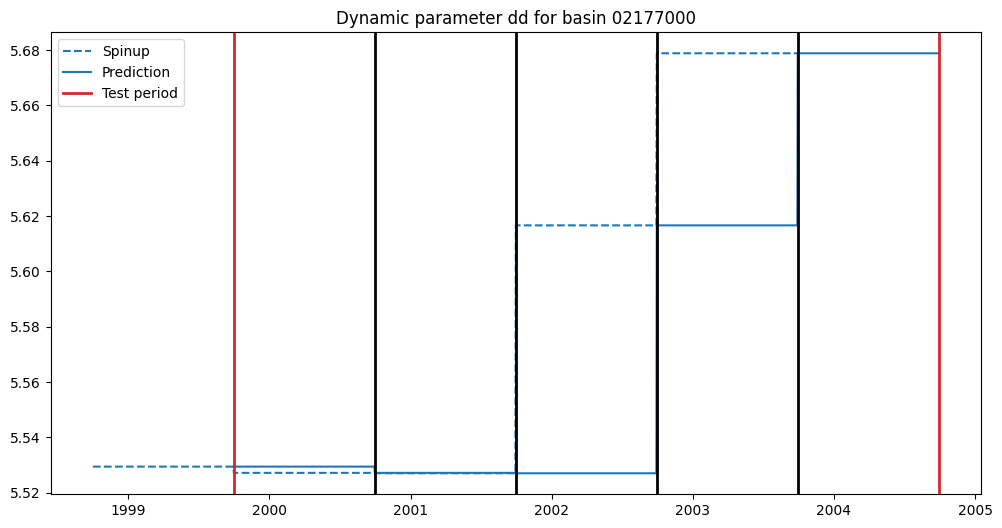

In [ ]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(dates[:-2], dd_spinup, color="tab:blue", label="Spinup", linestyle='--')
ax.plot(dates[:-2], dd_predict, color="tab:blue", label="Prediction")
ax.axvline(dates[365], color='tab:red', linewidth=2, label="Test period")
ax.axvline(dates[365*2], color='black', linewidth=2)
ax.axvline(dates[365*3], color='black', linewidth=2)
ax.axvline(dates[365*4], color='black', linewidth=2)
ax.axvline(dates[365*5], color='black', linewidth=2)
ax.axvline(dates[365*6], color='tab:red', linewidth=2)
ax.set_title(f"Dynamic parameter {param_interest} for basin {basin}")
ax.legend()

## Dynamic Parameters
Now let's test the same model and same training data, but with dynamic parameters

In [47]:
start_run(config_file=Path("2basin-test-dynamic.yml"), gpu=-1)

2026-03-02 17:52:30,635: Logging to /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology-dcfe/examples/08-SHM/runs/SHM_2basin_dynamic_0203_175230/output.log initialized.
2026-03-02 17:52:30,636: ### Folder structure created at /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology-dcfe/examples/08-SHM/runs/SHM_2basin_dynamic_0203_175230
2026-03-02 17:52:30,636: ### Run configurations for SHM_2basin_dynamic
2026-03-02 17:52:30,637: experiment_name: SHM_2basin_dynamic
2026-03-02 17:52:30,637: train_basin_file: 2_basin.txt
2026-03-02 17:52:30,638: validation_basin_file: 2_basin.txt
2026-03-02 17:52:30,638: test_basin_file: 2_basin.txt
2026-03-02 17:52:30,638: train_start_date: 2000-10-01 00:00:00
2026-03-02 17:52:30,639: train_end_date: 2014-09-30 00:00:00
2026-03-02 17:52:30,639: validation_start_date: 1990-10-01 00:00:00
2026-03-02 17:52:30,640: validation_

In [48]:
run_dir = Path("runs/SHM_2basin_dynamic_0203_175230")
tester = RegressionTester(run_dir=run_dir, cfg=Config(run_dir / "config.yml"))
tester.evaluate(save_all_output=True)

2026-03-02 18:01:15,054: Using the model weights from runs/SHM_2basin_dynamic_0203_175230/model_epoch010.pt
Metrics for 1D are calculated over last 1 elements only. Ignoring 364 predictions per sequence.
# Evaluation: 100%|██████████| 2/2 [00:03<00:00,  1.94s/it]
2026-03-02 18:01:18,935: Stored metrics at runs/SHM_2basin_dynamic_0203_175230/test/model_epoch010/test_metrics.csv
2026-03-02 18:01:18,938: Stored results at runs/SHM_2basin_dynamic_0203_175230/test/model_epoch010/test_results.p
2026-03-02 18:01:18,979: Stored states at runs/SHM_2basin_dynamic_0203_175230/test/model_epoch010/test_all_output.p


{'02177000': {'1D': {'xr': <xarray.Dataset> Size: 4MB
   Dimensions:         (date: 1463, time_step: 365)
   Coordinates:
     * date            (date) datetime64[ns] 12kB 2000-09-29 ... 2004-09-30
     * time_step       (time_step) int64 3kB -364 -363 -362 -361 ... -3 -2 -1 0
   Data variables:
       QObs(mm/d)_obs  (date, time_step) float32 2MB 0.9633 0.7989 ... 7.031 5.935
       QObs(mm/d)_sim  (date, time_step) float32 2MB 2.208 1.301 ... 6.891 5.697}},
 '02349900': {'1D': {'xr': <xarray.Dataset> Size: 4MB
   Dimensions:         (date: 1463, time_step: 365)
   Coordinates:
     * date            (date) datetime64[ns] 12kB 2000-09-29 ... 2004-09-30
     * time_step       (time_step) int64 3kB -364 -363 -362 -361 ... -3 -2 -1 0
   Data variables:
       QObs(mm/d)_obs  (date, time_step) float32 2MB 0.0861 0.084 ... 9.765 4.809
       QObs(mm/d)_sim  (date, time_step) float32 2MB 0.3978 0.3946 ... 10.24 5.054}}}

(1460,) (1460,)


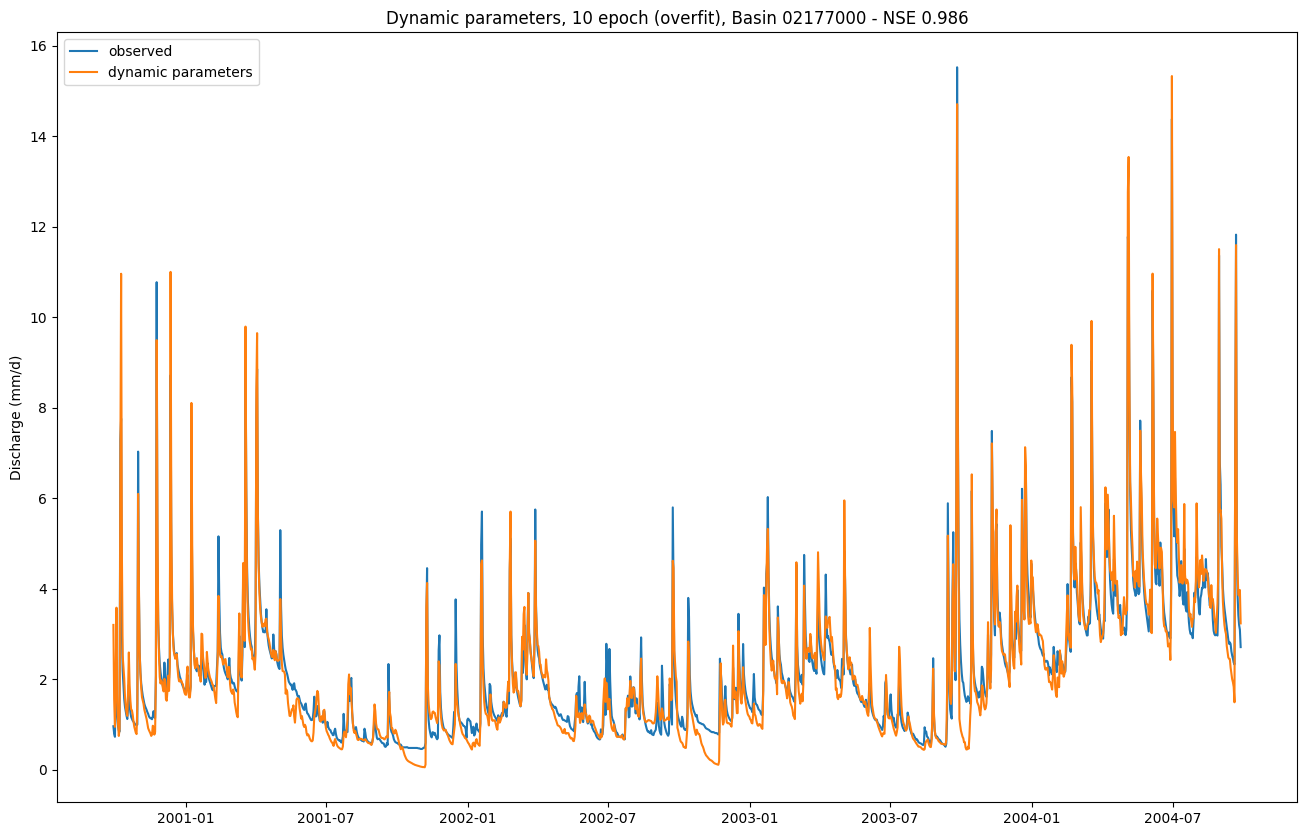

In [ ]:
with open(run_dir / "test" / "model_epoch010" / "test_all_output.p", "rb") as fp:
    dynamic_results = pickle.load(fp)
    


### Operational mode
Now test second parameter averaging scheme.

In [8]:
start_run(config_file=Path("2basin-test-operational.yml"), gpu=0)

2026-02-23 19:14:50,403: Logging to /home/adam/dev/repos/neuralhydrology-dcfe/examples/08-SHM/runs/test_SHM_2302_191450/output.log initialized.
2026-02-23 19:14:50,404: ### Folder structure created at /home/adam/dev/repos/neuralhydrology-dcfe/examples/08-SHM/runs/test_SHM_2302_191450
2026-02-23 19:14:50,404: ### Run configurations for test_SHM
2026-02-23 19:14:50,404: experiment_name: test_SHM
2026-02-23 19:14:50,405: train_basin_file: 2_basin.txt
2026-02-23 19:14:50,406: validation_basin_file: 2_basin.txt
2026-02-23 19:14:50,407: test_basin_file: 2_basin.txt
2026-02-23 19:14:50,408: train_start_date: 2000-10-01 00:00:00
2026-02-23 19:14:50,408: train_end_date: 2014-09-30 00:00:00
2026-02-23 19:14:50,408: validation_start_date: 1990-10-01 00:00:00
2026-02-23 19:14:50,409: validation_end_date: 1999-09-30 00:00:00
2026-02-23 19:14:50,409: test_start_date: 1999-10-01 00:00:00
2026-02-23 19:14:50,410: test_end_date: 2004-09-30 00:00:00
2026-02-23 19:14:50,410: device: cuda:0
2026-02-23 19:

In [9]:
run_dir = Path("runs/test_SHM_1802_114044")
eval_run(run_dir=run_dir, period="test")

2026-02-23 19:17:35,133: Using the model weights from runs/test_SHM_1802_114044/model_epoch010.pt
Metrics for 1D are calculated over last 1 elements only. Ignoring 364 predictions per sequence.
# Evaluation: 100%|██████████| 2/2 [00:04<00:00,  2.19s/it]
2026-02-23 19:17:39,533: Stored metrics at runs/test_SHM_1802_114044/test/model_epoch010/test_metrics.csv
2026-02-23 19:17:39,534: Stored results at runs/test_SHM_1802_114044/test/model_epoch010/test_results.p


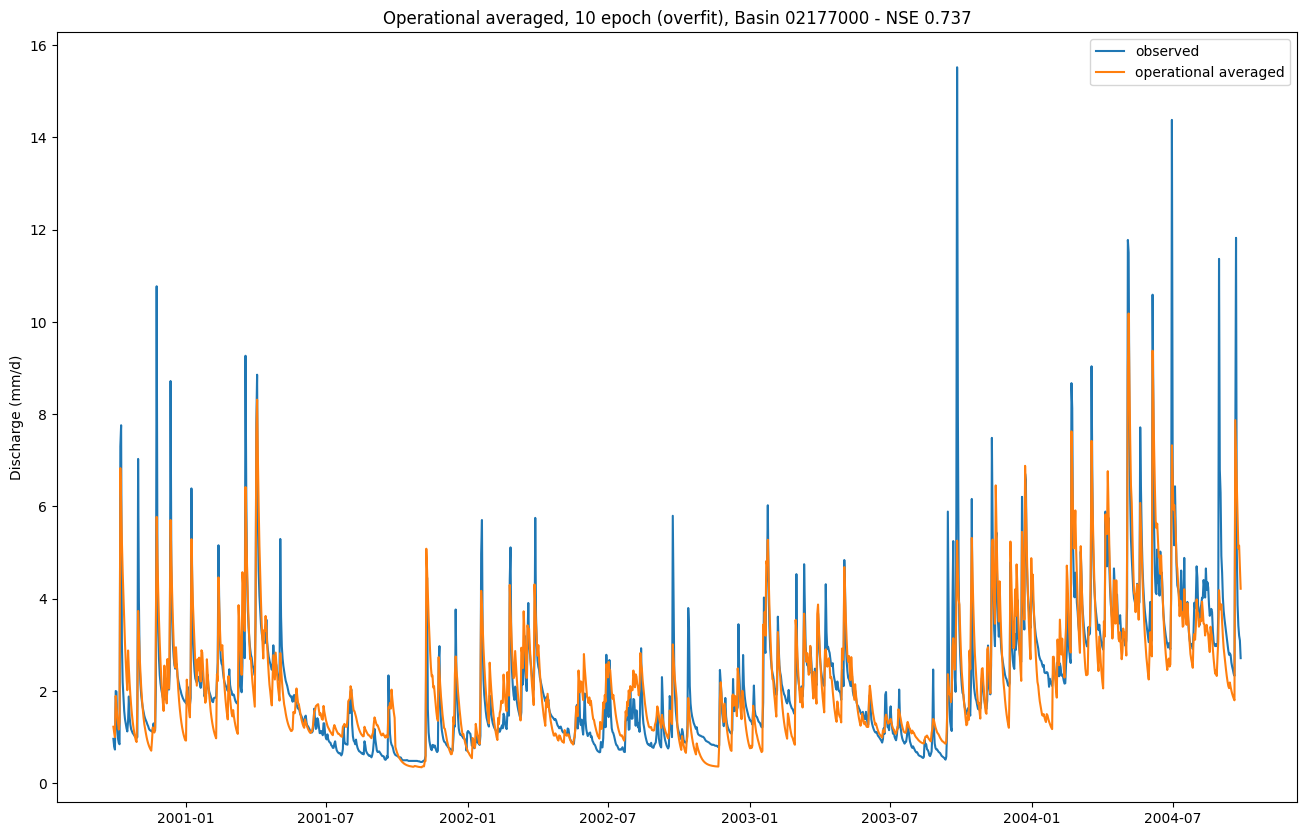

In [10]:
with open(run_dir / "test" / "model_epoch010" / "test_results.p", "rb") as fp:
    results = pickle.load(fp)
    
# Extract a data slice of observations and simulations
results_xr = results["02177000"]['1D']['xr']
qobs = results_xr['QObs(mm/d)_obs']
qsim_operational = results_xr['QObs(mm/d)_sim']

# extract observations and simulations
fig, ax = plt.subplots(figsize=(16,10))
ax.plot(results_xr["date"], qobs,label='observed')
ax.plot(results_xr["date"], qsim_operational,label='operational averaged')
ax.set_ylabel("Discharge (mm/d)")
ax.set_title(f"Operational averaged, 10 epoch (overfit), Basin 02177000 - NSE {results['02177000']['1D']['NSE']:.3f}")
ax.legend()

### Comparing dynamic vs oracle averaged
Let's plot them all on the same axes.

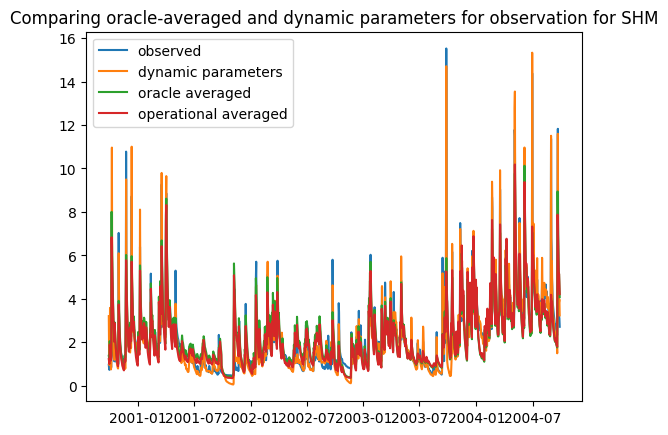

In [11]:
# extract observations and simulations
plt.plot(results_xr["date"], qobs,label='observed')
plt.plot(results_xr["date"], qsim_dynamic,label='dynamic parameters')
plt.plot(results_xr["date"], qsim_oracle, label='oracle averaged')
plt.plot(results_xr["date"], qsim_operational, label='operational averaged')
#plt.set_ylabel("Discharge (mm/d)")
plt.title("Comparing oracle-averaged and dynamic parameters for observation for SHM")
plt.legend()

# 531 Basins remove_overlapping_results test

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch.nn as nn

from neuralhydrology.utils.config import Config

import matplotlib.pyplot as plt
import torch
import xarray as xr
from neuralhydrology.nh_run import start_run, eval_run
import pickle

## Dynamic

In [19]:
lstm_benchmark_run_dir = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology-dcfe/examples/07-DCFE/runs/EXP1_LSTM_Full_CAMELS_Benchmark_2302_100517")
with open(lstm_benchmark_run_dir / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    lstm_benchmark_results = pickle.load(fp)
full_dynamic_shm_run_dir = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology-dcfe/examples/07-DCFE/runs/EXP1_SHM_CAMELS_531basin_Dynamic_1202_133700")
with open(full_dynamic_shm_run_dir / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    full_dynamic_shm_results = pickle.load(fp)
full_dynamic_shm_test_run_dir = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology-dcfe/examples/07-DCFE/runs/EXP1_SHM_CAMELS_531basin_Dynamic_1202_133700_test")
with open(full_dynamic_shm_test_run_dir / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    full_dynamic_shm_test_results = pickle.load(fp)

In [23]:
basin_keys = list(full_dynamic_shm_results.keys())
basin = basin_keys[0]
#full_dynamic_shm_results[basin]['1D']['xr']
full_dynamic_shm_test_results[basin]['1D']['xr']
#lstm_benchmark_results[basin]['1D']['xr'] #1461 long

<xarray.Dataset> Size: 35kB
Dimensions:         (datetime: 1460, date: 1097, time_step: 365)
Coordinates:
  * date            (date) datetime64[ns] 9kB 1999-09-30 ... 2002-09-30
  * time_step       (time_step) int64 3kB -364 -363 -362 -361 ... -3 -2 -1 0
  * datetime        (datetime) datetime64[ns] 12kB 1998-10-01 ... 2002-09-29
Data variables:
    QObs(mm/d)_obs  (datetime) float32 6kB 0.2456 0.5162 ... 0.4829 0.6661
    QObs(mm/d)_sim  (datetime) float32 6kB 0.479 0.7461 0.4531 ... 1.059 1.357

In [27]:
lstm_benchmark_results[basin]['1D']['xr']['QObs(mm/d)_obs']

<xarray.DataArray 'QObs(mm/d)_obs' (date: 1461, time_step: 1)> Size: 6kB
array([[0.24562502],
       [0.5162289 ],
       [0.47043443],
       ...,
       [0.48292387],
       [0.6661019 ],
       [0.47043443]], dtype=float32)
Coordinates:
  * date       (date) datetime64[ns] 12kB 1998-10-01 1998-10-02 ... 2002-09-30
  * time_step  (time_step) int64 8B 0

In [26]:
full_dynamic_shm_test_results[basin]['1D']['xr']['QObs(mm/d)_obs']

<xarray.DataArray 'QObs(mm/d)_obs' (datetime: 1460)> Size: 6kB
array([0.24562508, 0.516229  , 0.47043446, ..., 0.19983056, 0.48292387,
       0.6661019 ], dtype=float32)
Coordinates:
  * datetime  (datetime) datetime64[ns] 12kB 1998-10-01 ... 2002-09-29

In [36]:
# indicate values where they are unequal
basin = basin_keys[0]
lstm_obs = lstm_benchmark_results[basin]['1D']['xr']['QObs(mm/d)_obs'][:-1].squeeze() #remove last element here for consistent unit
adam_obs = full_dynamic_shm_test_results[basin]['1D']['xr']['QObs(mm/d)_obs']
not_equal_obs = np.sum(~np.isclose(lstm_obs, adam_obs, atol=1e-6))
not_equal_obs

0

In [35]:
lstm_obs

<xarray.DataArray 'QObs(mm/d)_obs' (date: 1460, time_step: 1)> Size: 6kB
array([[0.24562502],
       [0.5162289 ],
       [0.47043443],
       ...,
       [0.19983053],
       [0.48292387],
       [0.6661019 ]], dtype=float32)
Coordinates:
  * date       (date) datetime64[ns] 12kB 1998-10-01 1998-10-02 ... 2002-09-29
  * time_step  (time_step) int64 8B 0

In [38]:
passed_basins_sim = 0
failed_basins_sim = 0

passed_basins_obs = 0
failed_basins_obs = 0

for basin in basin_keys:
    # first comparing old manual code to
    full_result_xr = np.hstack([full_dynamic_shm_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
                               full_dynamic_shm_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
                               full_dynamic_shm_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
                                full_dynamic_shm_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    adam_result_xr = full_dynamic_shm_test_results[basin]['1D']['xr']['QObs(mm/d)_sim']
    
    # compare elementwise and record basins that are not equal, and how many values are not equal
    not_equal = np.sum(full_result_xr != adam_result_xr)
    if not_equal > 0:
        failed_basins_sim += 1
        print(f"Basin {basin} has {not_equal} unequal values.")
    # print total number of basins passed and total number of basins failed
    if not_equal == 0:
        passed_basins_sim += 1
    
    # comparing lstm benchmark observations to adam test results observations (used to ensure dates are correct)
    lstm_obs = lstm_benchmark_results[basin]['1D']['xr']['QObs(mm/d)_obs'][:-1].squeeze() #remove last element here for consistent unit
    adam_obs = full_dynamic_shm_test_results[basin]['1D']['xr']['QObs(mm/d)_obs']
    not_equal_obs = np.sum(~np.isclose(lstm_obs, adam_obs, atol=1e-6))
    if not_equal_obs > 0:
        print(f"Basin {basin} has {not_equal_obs} unequal observation values.")
        failed_basins_obs += 1
    if not_equal_obs == 0:
        passed_basins_obs += 1

print(f"\nTotal basins passed: {passed_basins_sim}")
print(f"Total basins failed: {failed_basins_sim}")
print(f"\nTotal basins passed (observations): {passed_basins_obs}")
print(f"Total basins failed (observations): {failed_basins_obs}")


Total basins passed: 531
Total basins failed: 0

Total basins passed (observations): 531
Total basins failed (observations): 0


## Averaging Schemes
First, Operational-Averaging.

In [39]:
full_operational_shm_run_dir = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology-dcfe/examples/07-DCFE/runs/EXP1_SHM_CAMELS_531basin_OperationalAvg_1702_160814")
with open(full_operational_shm_run_dir / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    full_operational_shm_results = pickle.load(fp)
full_operational_shm_test_run_dir = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology-dcfe/examples/07-DCFE/runs/EXP1_SHM_CAMELS_531basin_OperationalAvg_1702_160814_test")
with open(full_operational_shm_test_run_dir / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    full_operational_shm_test_results = pickle.load(fp)

In [40]:
passed_basins_sim = 0
failed_basins_sim = 0

passed_basins_obs = 0
failed_basins_obs = 0

for basin in basin_keys:
    # first comparing old manual code to
    full_result_xr = np.hstack([full_operational_shm_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
                               full_operational_shm_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
                               full_operational_shm_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
                                full_operational_shm_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    adam_result_xr = full_operational_shm_test_results[basin]['1D']['xr']['QObs(mm/d)_sim']
    
    # compare elementwise and record basins that are not equal, and how many values are not equal
    not_equal = np.sum(full_result_xr != adam_result_xr)
    if not_equal > 0:
        failed_basins_sim += 1
        print(f"Basin {basin} has {not_equal} unequal values.")
    # print total number of basins passed and total number of basins failed
    if not_equal == 0:
        passed_basins_sim += 1
    
    # comparing lstm benchmark observations to adam test results observations (used to ensure dates are correct)
    lstm_obs = lstm_benchmark_results[basin]['1D']['xr']['QObs(mm/d)_obs'][:-1].squeeze() #remove last element here for consistent unit
    adam_obs = full_operational_shm_test_results[basin]['1D']['xr']['QObs(mm/d)_obs']
    not_equal_obs = np.sum(~np.isclose(lstm_obs, adam_obs, atol=1e-6))
    if not_equal_obs > 0:
        print(f"Basin {basin} has {not_equal_obs} unequal observation values.")
        failed_basins_obs += 1
    if not_equal_obs == 0:
        passed_basins_obs += 1

print(f"\nTotal basins passed: {passed_basins_sim}")
print(f"Total basins failed: {failed_basins_sim}")
print(f"\nTotal basins passed (observations): {passed_basins_obs}")
print(f"Total basins failed (observations): {failed_basins_obs}")


Total basins passed: 531
Total basins failed: 0

Total basins passed (observations): 531
Total basins failed (observations): 0


Oracle-Averaging

In [41]:
full_oracle_shm_run_dir = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology-dcfe/examples/07-DCFE/runs/EXP1_SHM_CAMELS_531basin_OracleAvg_1702_232011")
with open(full_oracle_shm_run_dir / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    full_oracle_shm_results = pickle.load(fp)
full_oracle_shm_test_run_dir = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology-dcfe/examples/07-DCFE/runs/EXP1_SHM_CAMELS_531basin_OracleAvg_1702_232011_test")
with open(full_oracle_shm_test_run_dir / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    full_oracle_shm_test_results = pickle.load(fp)

In [44]:
passed_basins_sim = 0
failed_basins_sim = 0

passed_basins_obs = 0
failed_basins_obs = 0

for basin in basin_keys:
    # first comparing old manual code to
    full_result_xr = np.hstack([full_oracle_shm_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
                               full_oracle_shm_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
                               full_oracle_shm_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
                                full_oracle_shm_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    adam_result_xr = full_oracle_shm_test_results[basin]['1D']['xr']['QObs(mm/d)_sim']
    
    # compare elementwise and record basins that are not equal, and how many values are not equal
    not_equal = np.sum(full_result_xr != adam_result_xr)
    if not_equal > 0:
        failed_basins_sim += 1
        print(f"Basin {basin} has {not_equal} unequal values.")
    # print total number of basins passed and total number of basins failed
    if not_equal == 0:
        passed_basins_sim += 1
    
    # comparing lstm benchmark observations to adam test results observations (used to ensure dates are correct)
    lstm_obs = lstm_benchmark_results[basin]['1D']['xr']['QObs(mm/d)_obs'][:-1].squeeze() #remove last element here for consistent unit
    adam_obs = full_oracle_shm_test_results[basin]['1D']['xr']['QObs(mm/d)_obs']
    not_equal_obs = np.sum(~np.isclose(lstm_obs, adam_obs, atol=1e-6))
    if not_equal_obs > 0:
        print(f"Basin {basin} has {not_equal_obs} unequal observation values.")
        failed_basins_obs += 1
    if not_equal_obs == 0:
        passed_basins_obs += 1

print(f"\nTotal basins passed: {passed_basins_sim}")
print(f"Total basins failed: {failed_basins_sim}")
print(f"\nTotal basins passed (observations): {passed_basins_obs}")
print(f"Total basins failed (observations): {failed_basins_obs}")


Total basins passed: 531
Total basins failed: 0

Total basins passed (observations): 531
Total basins failed (observations): 0


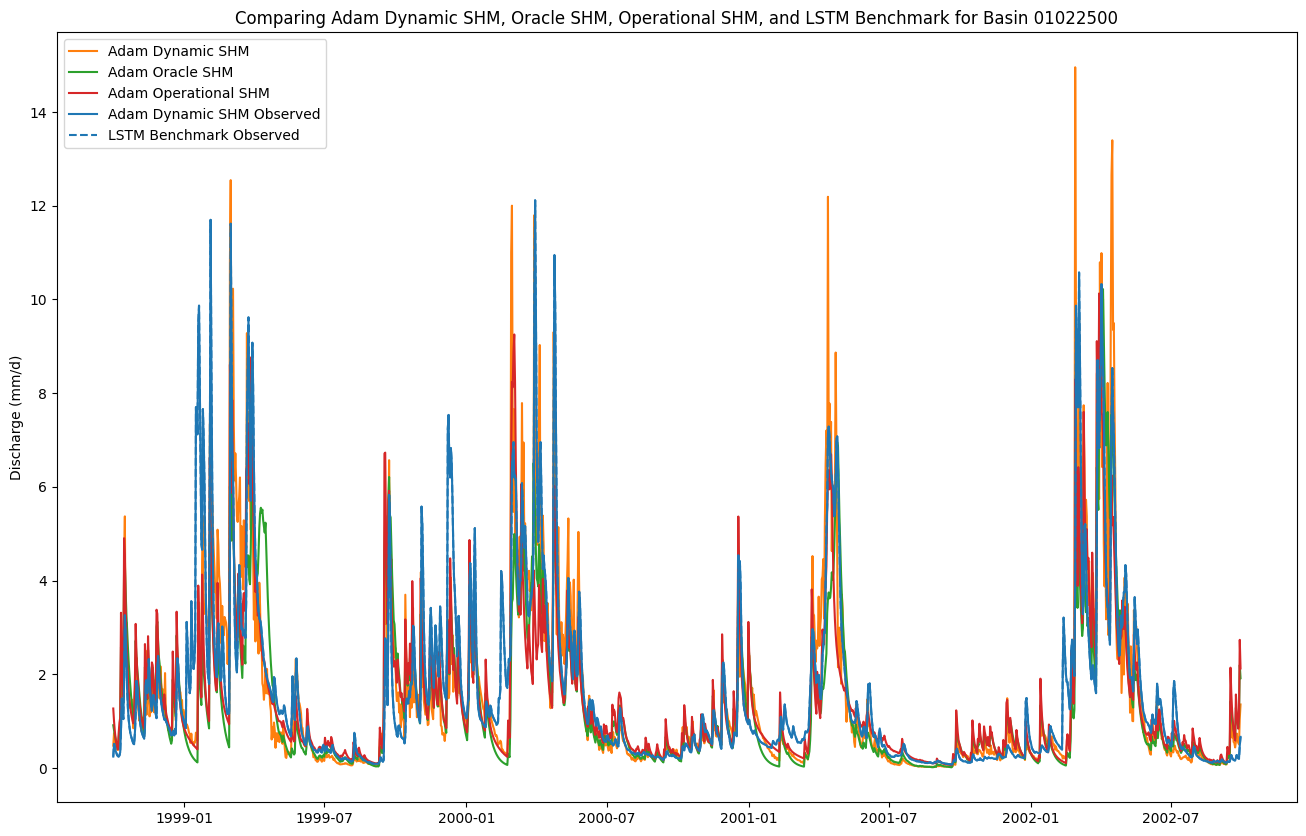

In [58]:
basin = basin_keys[0]
plotting_dates = full_dynamic_shm_test_results[basin]['1D']['xr']['QObs(mm/d)_sim'].datetime
Adam_dynamic_shm = full_dynamic_shm_test_results[basin]['1D']['xr']['QObs(mm/d)_sim']
Adam_oracle_shm = full_oracle_shm_test_results[basin]['1D']['xr']['QObs(mm/d)_sim']
Adam_operational_shm = full_operational_shm_test_results[basin]['1D']['xr']['QObs(mm/d)_sim']
benchmark_lstm = lstm_benchmark_results[basin]['1D']['xr']['QObs(mm/d)_sim'][:-1].squeeze() #remove last element here for consistent unit
lstm_obs = lstm_benchmark_results[basin]['1D']['xr']['QObs(mm/d)_obs'][:-1].squeeze() #remove last element here for consistent unit
Adam_dynamic_shm_obs = full_dynamic_shm_test_results[basin]['1D']['xr']['QObs(mm/d)_obs']

fig, ax = plt.subplots(figsize=(16,10))
ax.plot(plotting_dates, Adam_dynamic_shm,label='Adam Dynamic SHM',
        color='tab:orange')
ax.plot(plotting_dates, Adam_oracle_shm,label='Adam Oracle SHM',
        color='tab:green')
ax.plot(plotting_dates, Adam_operational_shm,label='Adam Operational SHM',
        color='tab:red')
ax.plot(plotting_dates, Adam_dynamic_shm_obs,label='Adam Dynamic SHM Observed', 
        color='tab:blue')
ax.plot(plotting_dates, lstm_obs,label='LSTM Benchmark Observed', 
        color='tab:blue', linestyle = '--')
ax.set_ylabel("Discharge (mm/d)")
ax.set_title(f"Comparing Adam Dynamic SHM, Oracle SHM, Operational SHM, and LSTM Benchmark for Basin {basin}")
ax.legend()


# Parameters and States

## Oracle Mode

In [ ]:
run_dir = Path("runs/test_SHM_2901_134126")
from neuralhydrology.evaluation.tester import RegressionTester
tester = RegressionTester(run_dir=run_dir, cfg=Config(run_dir / "config.yml"))
#tester.evaluate(save_all_output=True)
with open(run_dir / "test" / "model_epoch010" / "test_all_output.p", "rb") as fp:
    oracle_results = pickle.load(fp)

2026-03-02 18:06:39,988: Using the model weights from runs/test_SHM_2901_134126/model_epoch010.pt
Metrics for 1D are calculated over last 1 elements only. Ignoring 364 predictions per sequence.
# Evaluation: 100%|██████████| 2/2 [00:06<00:00,  3.32s/it]
2026-03-02 18:06:46,638: Stored metrics at runs/test_SHM_2901_134126/test/model_epoch010/test_metrics.csv
2026-03-02 18:06:46,646: Stored results at runs/test_SHM_2901_134126/test/model_epoch010/test_results.p
2026-03-02 18:06:46,741: Stored states at runs/test_SHM_2901_134126/test/model_epoch010/test_all_output.p


In [61]:
param_keys = list(oracle_results[basin]["parameters"].keys())

In [62]:
param_interest = param_keys[0]
dd_spinup_oracle = xr.DataArray(
    np.hstack(
        [oracle_results[basin]["parameters"][param_interest][0][0:365],
         oracle_results[basin]["parameters"][param_interest][365][0:365],
         oracle_results[basin]["parameters"][param_interest][365*2][0:365],
         oracle_results[basin]["parameters"][param_interest][365*3][0:365],
         oracle_results[basin]["parameters"][param_interest][365*4][0:365],
         np.full(365, np.nan)]
        )
) # this is 2190 long

dd_predict_oracle = xr.DataArray(
    np.hstack(
        [np.full(365, np.nan),
        oracle_results[basin]["parameters"][param_interest][0][-365:],
        oracle_results[basin]["parameters"][param_interest][365][-365:],
        oracle_results[basin]["parameters"][param_interest][365*2][-365:],
        oracle_results[basin]["parameters"][param_interest][365*3][-365:],
        oracle_results[basin]["parameters"][param_interest][365*4][-365:]]
            )
) # this is 2190 long

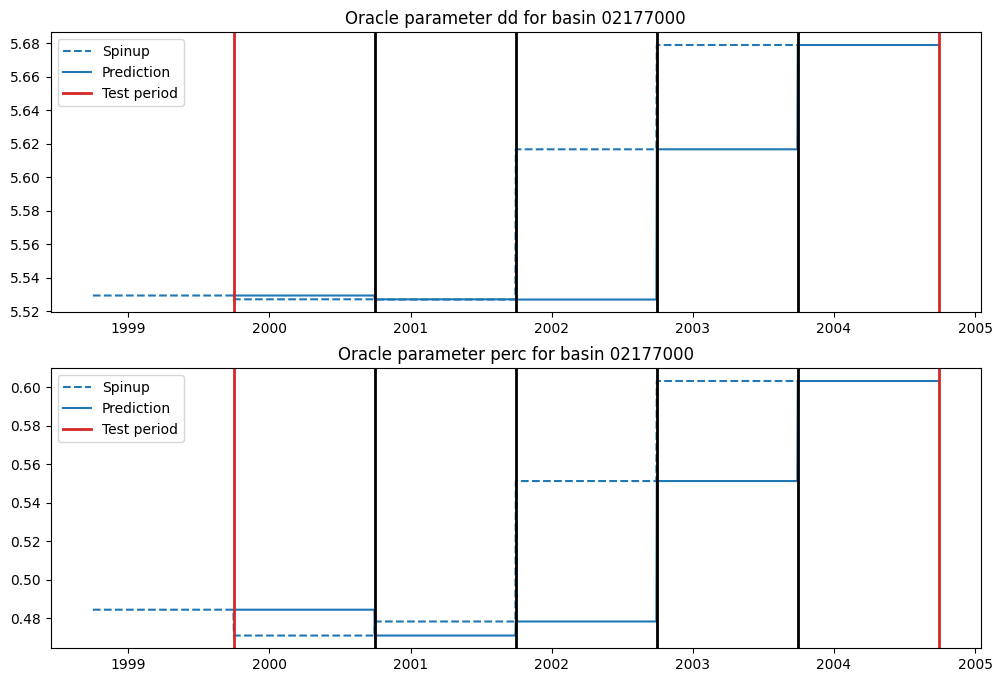

In [71]:
param_interest = param_keys[4]
param_spinup_oracle = xr.DataArray(
    np.hstack(
        [oracle_results[basin]["parameters"][param_interest][0][0:365],
         oracle_results[basin]["parameters"][param_interest][365][0:365],
         oracle_results[basin]["parameters"][param_interest][365*2][0:365],
         oracle_results[basin]["parameters"][param_interest][365*3][0:365],
         oracle_results[basin]["parameters"][param_interest][365*4][0:365],
         np.full(365, np.nan)]
        )
) # this is 2190 long

param_predict_oracle = xr.DataArray(
    np.hstack(
        [np.full(365, np.nan),
        oracle_results[basin]["parameters"][param_interest][0][-365:],
        oracle_results[basin]["parameters"][param_interest][365][-365:],
        oracle_results[basin]["parameters"][param_interest][365*2][-365:],
        oracle_results[basin]["parameters"][param_interest][365*3][-365:],
        oracle_results[basin]["parameters"][param_interest][365*4][-365:]]
            )
) # this is 2190 long

fig, ax = plt.subplots(figsize=(12,8), nrows=2, ncols=1)
ax[0].plot(dates[:-2], dd_spinup_oracle, color="tab:blue", label="Spinup", linestyle='--')
ax[0].plot(dates[:-2], dd_predict_oracle, color="tab:blue", label="Prediction")
ax[0].axvline(dates[365], color='tab:red', linewidth=2, label="Test period")
ax[0].axvline(dates[365*2], color='black', linewidth=2)
ax[0].axvline(dates[365*3], color='black', linewidth=2)
ax[0].axvline(dates[365*4], color='black', linewidth=2)
ax[0].axvline(dates[365*5], color='black', linewidth=2)
ax[0].axvline(dates[365*6], color='tab:red', linewidth=2)
ax[0].set_title(f"Oracle parameter dd for basin {basin}")
ax[0].legend()

ax[1].plot(dates[:-2], param_spinup_oracle, color="tab:blue", label="Spinup", linestyle='--')
ax[1].plot(dates[:-2], param_predict_oracle, color="tab:blue", label="Prediction")
ax[1].axvline(dates[365], color='tab:red', linewidth=2, label="Test period")
ax[1].axvline(dates[365*2], color='black', linewidth=2)
ax[1].axvline(dates[365*3], color='black', linewidth=2)
ax[1].axvline(dates[365*4], color='black', linewidth=2)
ax[1].axvline(dates[365*5], color='black', linewidth=2)
ax[1].axvline(dates[365*6], color='tab:red', linewidth=2)
ax[1].set_title(f"Oracle parameter {param_interest} for basin {basin}")
ax[1].legend()

In [88]:
state_keys = list(oracle_results[basin]['internal_states'].keys())
state_interest = state_keys[1]
sf_spinup_oracle = xr.DataArray(
    np.hstack(
        [oracle_results[basin]['internal_states'][state_interest][0][0:365],
         oracle_results[basin]['internal_states'][state_interest][365][0:365],
         oracle_results[basin]['internal_states'][state_interest][365*2][0:365],
         oracle_results[basin]['internal_states'][state_interest][365*3][0:365],
         oracle_results[basin]['internal_states'][state_interest][365*4][0:365],
         np.full(365, np.nan)]
        )
) # this is 2190 long
sf_predict_oracle = xr.DataArray(
    np.hstack(
        [np.full(365, np.nan),
        oracle_results[basin]['internal_states'][state_interest][0][-365:],
        oracle_results[basin]['internal_states'][state_interest][365][-365:],
        oracle_results[basin]['internal_states'][state_interest][365*2][-365:],
        oracle_results[basin]['internal_states'][state_interest][365*3][-365:],
        oracle_results[basin]['internal_states'][state_interest][365*4][-365:]]
            )
) # this is 2190 long

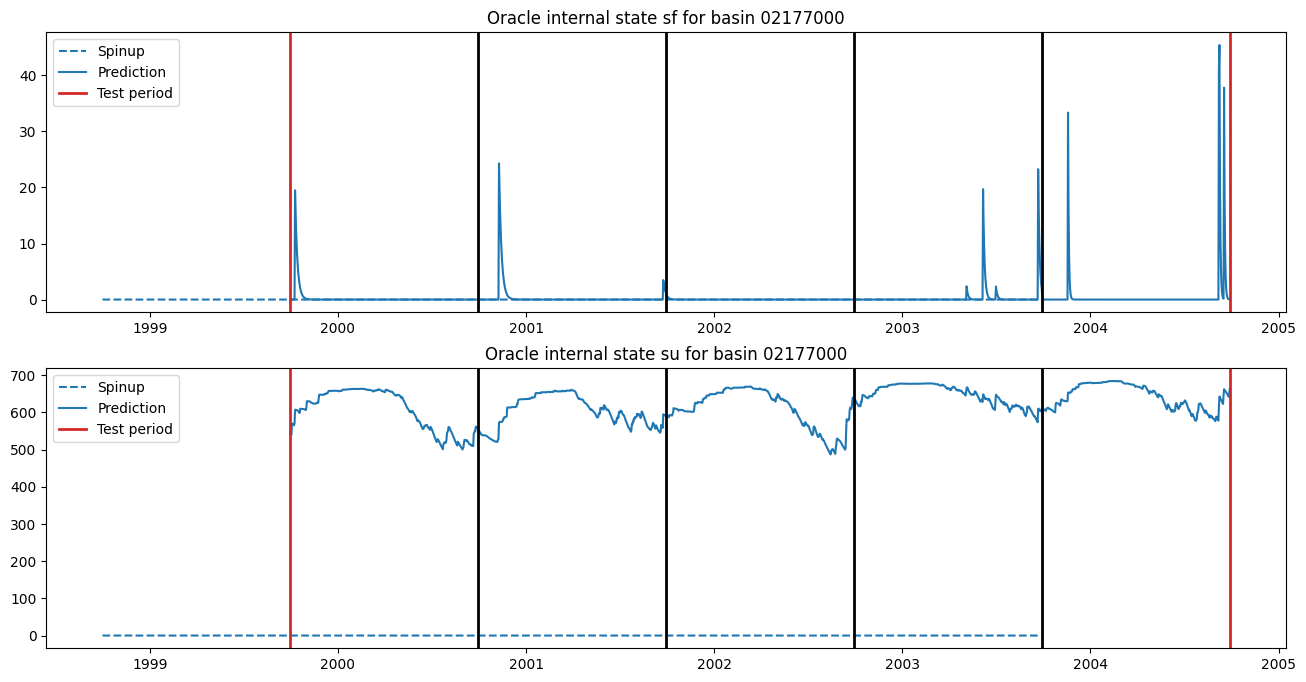

In [89]:
state_interest = state_keys[2]
state_spinup_oracle = xr.DataArray(
    np.hstack(
        [oracle_results[basin]['internal_states'][state_interest][0][0:365],
         oracle_results[basin]['internal_states'][state_interest][365][0:365],
         oracle_results[basin]['internal_states'][state_interest][365*2][0:365],
         oracle_results[basin]['internal_states'][state_interest][365*3][0:365],
         oracle_results[basin]['internal_states'][state_interest][365*4][0:365],
         np.full(365, np.nan)]
        )
) # this is 2190 long
state_predict_oracle = xr.DataArray(
    np.hstack(
        [np.full(365, np.nan),
        oracle_results[basin]['internal_states'][state_interest][0][-365:],
        oracle_results[basin]['internal_states'][state_interest][365][-365:],
        oracle_results[basin]['internal_states'][state_interest][365*2][-365:],
        oracle_results[basin]['internal_states'][state_interest][365*3][-365:],
        oracle_results[basin]['internal_states'][state_interest][365*4][-365:]]
            )
) # this is 2190 long

fig, ax = plt.subplots(figsize=(16,8), nrows=2, ncols=1)
ax[0].plot(dates[:-2], sf_spinup_oracle, color="tab:blue", label="Spinup", linestyle='--')
ax[0].plot(dates[:-2], sf_predict_oracle, color="tab:blue", label="Prediction")
ax[0].axvline(dates[365], color='tab:red', linewidth=2, label="Test period")
ax[0].axvline(dates[365*2], color='black', linewidth=2)
ax[0].axvline(dates[365*3], color='black', linewidth=2)
ax[0].axvline(dates[365*4], color='black', linewidth=2)
ax[0].axvline(dates[365*5], color='black', linewidth=2)
ax[0].axvline(dates[365*6], color='tab:red', linewidth=2)
ax[0].set_title(f"Oracle internal state sf for basin {basin}")
ax[0].legend()

ax[1].plot(dates[:-2], state_spinup_oracle, color="tab:blue", label="Spinup", linestyle='--')
ax[1].plot(dates[:-2], state_predict_oracle, color="tab:blue", label="Prediction")
ax[1].axvline(dates[365], color='tab:red', linewidth=2, label="Test period")
ax[1].axvline(dates[365*2], color='black', linewidth=2)
ax[1].axvline(dates[365*3], color='black', linewidth=2)
ax[1].axvline(dates[365*4], color='black', linewidth=2)
ax[1].axvline(dates[365*5], color='black', linewidth=2)
ax[1].axvline(dates[365*6], color='tab:red', linewidth=2)
ax[1].set_title(f"Oracle internal state {state_interest} for basin {basin}")
ax[1].legend()

## Dynamic Mode

In [82]:
run_dir = Path("runs/SHM_2basin_dynamic_0203_175230")
#tester = RegressionTester(run_dir=run_dir, cfg=Config(run_dir / "config.yml"))
#tester.evaluate(save_all_output=True)
with open(run_dir / "test" / "model_epoch010" / "test_all_output.p", "rb") as fp:
    dynamic_results = pickle.load(fp)

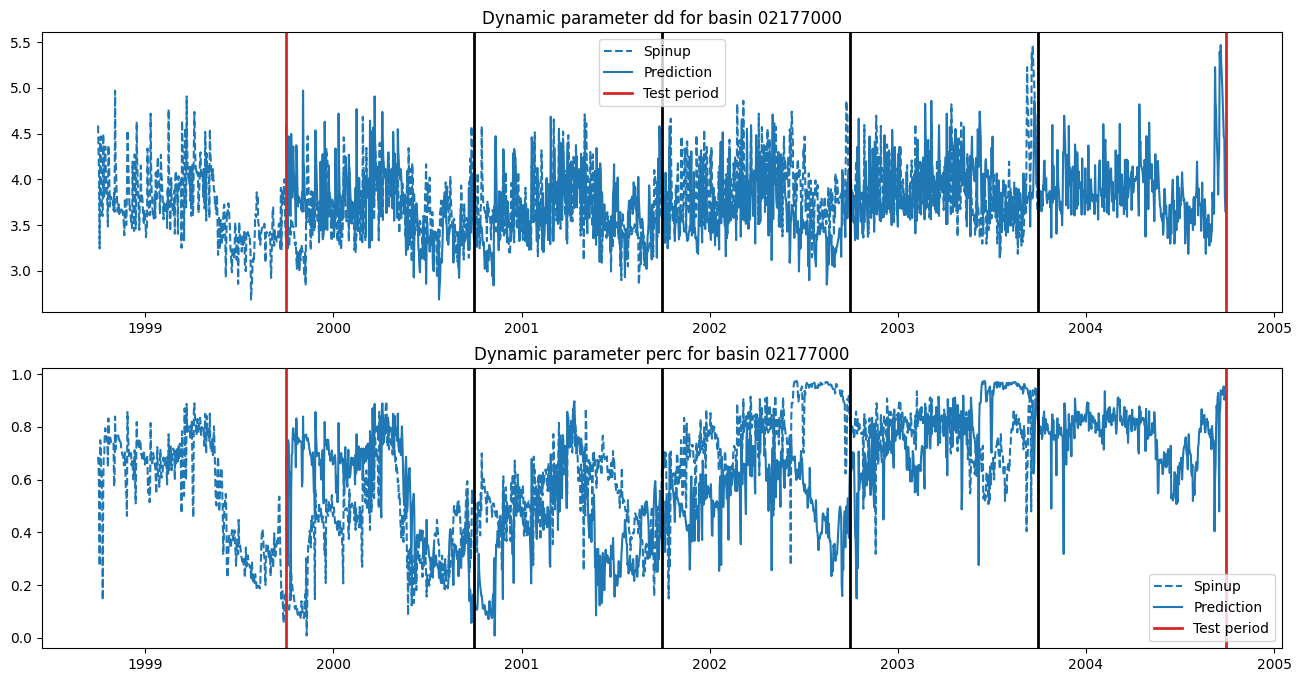

In [86]:
param_interest = param_keys[0]
dd_spinup_dynamic = xr.DataArray(
    np.hstack(
        [dynamic_results[basin]["parameters"][param_interest][0][0:365],
         dynamic_results[basin]["parameters"][param_interest][365][0:365],
         dynamic_results[basin]["parameters"][param_interest][365*2][0:365],
         dynamic_results[basin]["parameters"][param_interest][365*3][0:365],
         dynamic_results[basin]["parameters"][param_interest][365*4][0:365],
         np.full(365, np.nan)]
        )
) # this is 2190 long

dd_predict_dynamic = xr.DataArray(
    np.hstack(
        [np.full(365, np.nan),
        dynamic_results[basin]["parameters"][param_interest][0][-365:],
        dynamic_results[basin]["parameters"][param_interest][365][-365:],
        dynamic_results[basin]["parameters"][param_interest][365*2][-365:],
        dynamic_results[basin]["parameters"][param_interest][365*3][-365:],
        dynamic_results[basin]["parameters"][param_interest][365*4][-365:]]
            )
) # this is 2190 long

param_interest = param_keys[4]
param_spinup_dynamic = xr.DataArray(
    np.hstack(
        [dynamic_results[basin]["parameters"][param_interest][0][0:365],
         dynamic_results[basin]["parameters"][param_interest][365][0:365],
         dynamic_results[basin]["parameters"][param_interest][365*2][0:365],
         dynamic_results[basin]["parameters"][param_interest][365*3][0:365],
         dynamic_results[basin]["parameters"][param_interest][365*4][0:365],
         np.full(365, np.nan)]
        )
) # this is 2190 long

param_predict_dynamic = xr.DataArray(
    np.hstack(
        [np.full(365, np.nan),
        dynamic_results[basin]["parameters"][param_interest][0][-365:],
        dynamic_results[basin]["parameters"][param_interest][365][-365:],
        dynamic_results[basin]["parameters"][param_interest][365*2][-365:],
        dynamic_results[basin]["parameters"][param_interest][365*3][-365:],
        dynamic_results[basin]["parameters"][param_interest][365*4][-365:]]
            )
) # this is 2190 long

fig, ax = plt.subplots(figsize=(16,8), nrows=2, ncols=1)
ax[0].plot(dates[:-2], dd_spinup_dynamic, color="tab:blue", label="Spinup", linestyle='--')
ax[0].plot(dates[:-2], dd_predict_dynamic, color="tab:blue", label="Prediction")
ax[0].axvline(dates[365], color='tab:red', linewidth=2, label="Test period")
ax[0].axvline(dates[365*2], color='black', linewidth=2)
ax[0].axvline(dates[365*3], color='black', linewidth=2)
ax[0].axvline(dates[365*4], color='black', linewidth=2)
ax[0].axvline(dates[365*5], color='black', linewidth=2)
ax[0].axvline(dates[365*6], color='tab:red', linewidth=2)
ax[0].set_title(f"Dynamic parameter dd for basin {basin}")
ax[0].legend()

ax[1].plot(dates[:-2], param_spinup_dynamic, color="tab:blue", label="Spinup", linestyle='--')
ax[1].plot(dates[:-2], param_predict_dynamic, color="tab:blue", label="Prediction")
ax[1].axvline(dates[365], color='tab:red', linewidth=2, label="Test period")
ax[1].axvline(dates[365*2], color='black', linewidth=2)
ax[1].axvline(dates[365*3], color='black', linewidth=2)
ax[1].axvline(dates[365*4], color='black', linewidth=2)
ax[1].axvline(dates[365*5], color='black', linewidth=2)
ax[1].axvline(dates[365*6], color='tab:red', linewidth=2)
ax[1].set_title(f"Dynamic parameter {param_interest} for basin {basin}")
ax[1].legend()

In [90]:
state_interest = state_keys[1]
sf_spinup_dynamic = xr.DataArray(
    np.hstack(
        [dynamic_results[basin]['internal_states'][state_interest][0][0:365],
         dynamic_results[basin]['internal_states'][state_interest][365][0:365],
         dynamic_results[basin]['internal_states'][state_interest][365*2][0:365],
         dynamic_results[basin]['internal_states'][state_interest][365*3][0:365],
         dynamic_results[basin]['internal_states'][state_interest][365*4][0:365],
         np.full(365, np.nan)]
        )
) # this is 2190 long
sf_predict_dynamic = xr.DataArray(
    np.hstack(
        [np.full(365, np.nan),
        dynamic_results[basin]['internal_states'][state_interest][0][-365:],
        dynamic_results[basin]['internal_states'][state_interest][365][-365:],
        dynamic_results[basin]['internal_states'][state_interest][365*2][-365:],
        dynamic_results[basin]['internal_states'][state_interest][365*3][-365:],
        dynamic_results[basin]['internal_states'][state_interest][365*4][-365:]]
            )
) # this is 2190 long

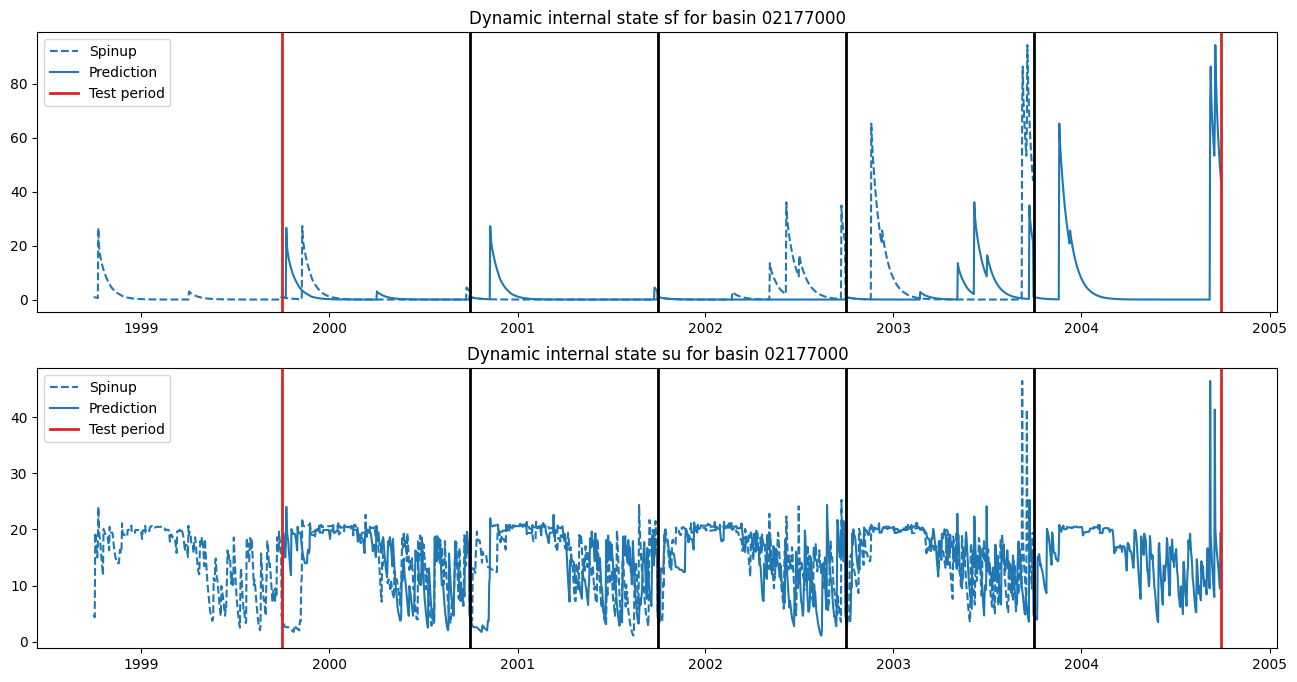

In [92]:
state_interest = state_keys[2]
state_spinup_dynamic = xr.DataArray(
    np.hstack(
        [dynamic_results[basin]['internal_states'][state_interest][0][0:365],
         dynamic_results[basin]['internal_states'][state_interest][365][0:365],
         dynamic_results[basin]['internal_states'][state_interest][365*2][0:365],
         dynamic_results[basin]['internal_states'][state_interest][365*3][0:365],
         dynamic_results[basin]['internal_states'][state_interest][365*4][0:365],
         np.full(365, np.nan)]
        )
) # this is 2190 long
state_predict_dynamic = xr.DataArray(
    np.hstack(
        [np.full(365, np.nan),
        dynamic_results[basin]['internal_states'][state_interest][0][-365:],
        dynamic_results[basin]['internal_states'][state_interest][365][-365:],
        dynamic_results[basin]['internal_states'][state_interest][365*2][-365:],
        dynamic_results[basin]['internal_states'][state_interest][365*3][-365:],
        dynamic_results[basin]['internal_states'][state_interest][365*4][-365:]]
            )
) # this is 2190 long

fig, ax = plt.subplots(figsize=(16,8), nrows=2, ncols=1)
ax[0].plot(dates[:-2], sf_spinup_dynamic, color="tab:blue", label="Spinup", linestyle='--')
ax[0].plot(dates[:-2], sf_predict_dynamic, color="tab:blue", label="Prediction")
ax[0].axvline(dates[365], color='tab:red', linewidth=2, label="Test period")
ax[0].axvline(dates[365*2], color='black', linewidth=2)
ax[0].axvline(dates[365*3], color='black', linewidth=2)
ax[0].axvline(dates[365*4], color='black', linewidth=2)
ax[0].axvline(dates[365*5], color='black', linewidth=2)
ax[0].axvline(dates[365*6], color='tab:red', linewidth=2)
ax[0].set_title(f"Dynamic internal state sf for basin {basin}")
ax[0].legend()

ax[1].plot(dates[:-2], state_spinup_dynamic, color="tab:blue", label="Spinup", linestyle='--')
ax[1].plot(dates[:-2], state_predict_dynamic, color="tab:blue", label="Prediction")
ax[1].axvline(dates[365], color='tab:red', linewidth=2, label="Test period")
ax[1].axvline(dates[365*2], color='black', linewidth=2)
ax[1].axvline(dates[365*3], color='black', linewidth=2)
ax[1].axvline(dates[365*4], color='black', linewidth=2)
ax[1].axvline(dates[365*5], color='black', linewidth=2)
ax[1].axvline(dates[365*6], color='tab:red', linewidth=2)
ax[1].set_title(f"Dynamic internal state {state_interest} for basin {basin}")
ax[1].legend()

## Operational Mode

In [93]:
start_run(config_file=Path("2basin-test-operational.yml"), gpu=-1)

2026-03-02 19:28:15,497: Logging to /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology-dcfe/examples/08-SHM/runs/SHM_2basin_operational_0203_192815/output.log initialized.
2026-03-02 19:28:15,499: ### Folder structure created at /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology-dcfe/examples/08-SHM/runs/SHM_2basin_operational_0203_192815
2026-03-02 19:28:15,500: ### Run configurations for SHM_2basin_operational
2026-03-02 19:28:15,501: experiment_name: SHM_2basin_operational
2026-03-02 19:28:15,501: train_basin_file: 2_basin.txt
2026-03-02 19:28:15,502: validation_basin_file: 2_basin.txt
2026-03-02 19:28:15,502: test_basin_file: 2_basin.txt
2026-03-02 19:28:15,503: train_start_date: 2000-10-01 00:00:00
2026-03-02 19:28:15,503: train_end_date: 2014-09-30 00:00:00
2026-03-02 19:28:15,503: validation_start_date: 1990-10-01 00:00:00
2026-03-02 19:28:15,

In [ ]:
run_dir = Path("runs/SHM_2basin_operational_0203_192815")
tester = RegressionTester(run_dir=run_dir, cfg=Config(run_dir / "config.yml"))
#tester.evaluate(save_all_output=True)
with open(run_dir / "test" / "model_epoch010" / "test_all_output.p", "rb") as fp:
    operational_results = pickle.load(fp)

2026-03-02 19:38:40,783: Using the model weights from runs/SHM_2basin_operational_0203_192815/model_epoch010.pt
Metrics for 1D are calculated over last 1 elements only. Ignoring 364 predictions per sequence.
# Evaluation: 100%|██████████| 2/2 [00:06<00:00,  3.27s/it]
2026-03-02 19:38:47,335: Stored metrics at runs/SHM_2basin_operational_0203_192815/test/model_epoch010/test_metrics.csv
2026-03-02 19:38:47,338: Stored results at runs/SHM_2basin_operational_0203_192815/test/model_epoch010/test_results.p
2026-03-02 19:38:47,374: Stored states at runs/SHM_2basin_operational_0203_192815/test/model_epoch010/test_all_output.p


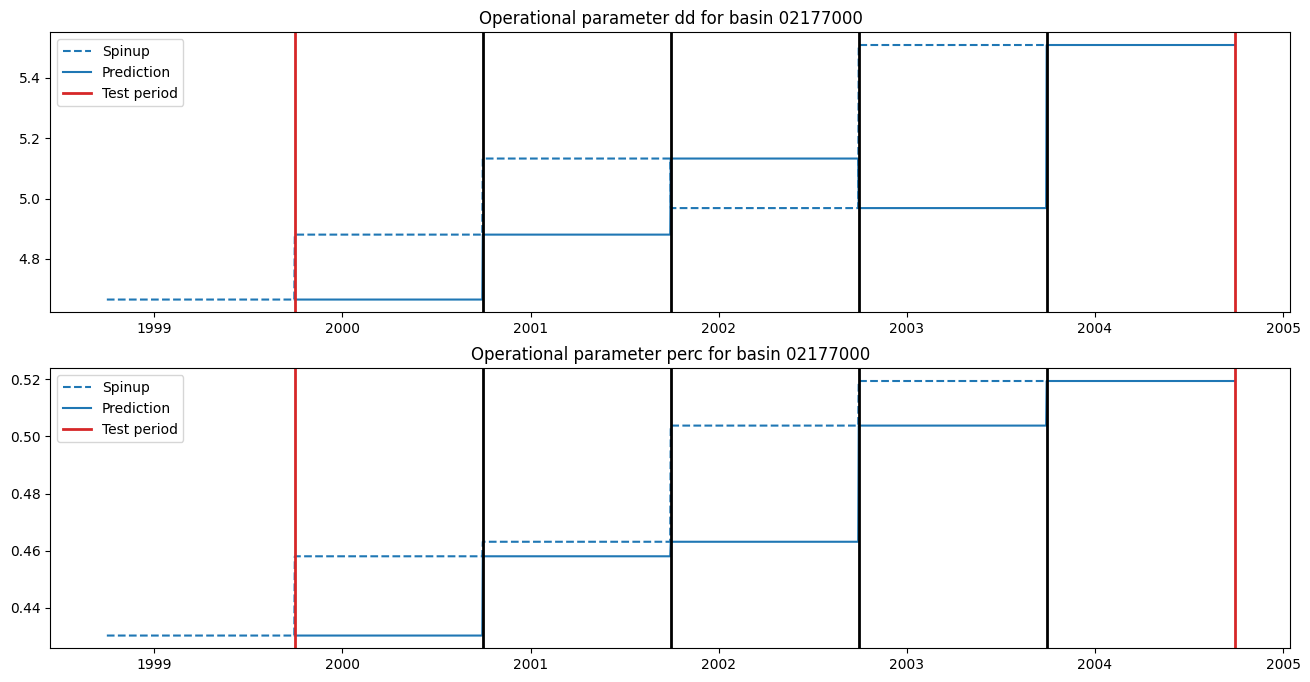

In [98]:
param_interest = param_keys[0]
dd_spinup_operational = xr.DataArray(
    np.hstack(
        [operational_results[basin]["parameters"][param_interest][0][0:365],
         operational_results[basin]["parameters"][param_interest][365][0:365],
         operational_results[basin]["parameters"][param_interest][365*2][0:365],
         operational_results[basin]["parameters"][param_interest][365*3][0:365],
         operational_results[basin]["parameters"][param_interest][365*4][0:365],
         np.full(365, np.nan)]
        )
) # this is 2190 long

dd_predict_operational = xr.DataArray(
    np.hstack(
        [np.full(365, np.nan),
        operational_results[basin]["parameters"][param_interest][0][-365:],
        operational_results[basin]["parameters"][param_interest][365][-365:],
        operational_results[basin]["parameters"][param_interest][365*2][-365:],
        operational_results[basin]["parameters"][param_interest][365*3][-365:],
        operational_results[basin]["parameters"][param_interest][365*4][-365:]]
            )
) # this is 2190 long

param_interest = param_keys[4]
param_spinup_operational = xr.DataArray(
    np.hstack(
        [operational_results[basin]["parameters"][param_interest][0][0:365],
         operational_results[basin]["parameters"][param_interest][365][0:365],
         operational_results[basin]["parameters"][param_interest][365*2][0:365],
         operational_results[basin]["parameters"][param_interest][365*3][0:365],
         operational_results[basin]["parameters"][param_interest][365*4][0:365],
         np.full(365, np.nan)]
        )
) # this is 2190 long

param_predict_operational = xr.DataArray(
    np.hstack(
        [np.full(365, np.nan),
        operational_results[basin]["parameters"][param_interest][0][-365:],
        operational_results[basin]["parameters"][param_interest][365][-365:],
        operational_results[basin]["parameters"][param_interest][365*2][-365:],
        operational_results[basin]["parameters"][param_interest][365*3][-365:],
        operational_results[basin]["parameters"][param_interest][365*4][-365:]]
            )
) # this is 2190 long

fig, ax = plt.subplots(figsize=(16,8), nrows=2, ncols=1)
ax[0].plot(dates[:-2], dd_spinup_operational, color="tab:blue", label="Spinup", linestyle='--')
ax[0].plot(dates[:-2], dd_predict_operational, color="tab:blue", label="Prediction")
ax[0].axvline(dates[365], color='tab:red', linewidth=2, label="Test period")
ax[0].axvline(dates[365*2], color='black', linewidth=2)
ax[0].axvline(dates[365*3], color='black', linewidth=2)
ax[0].axvline(dates[365*4], color='black', linewidth=2)
ax[0].axvline(dates[365*5], color='black', linewidth=2)
ax[0].axvline(dates[365*6], color='tab:red', linewidth=2)
ax[0].set_title(f"Operational parameter dd for basin {basin}")
ax[0].legend()

ax[1].plot(dates[:-2], param_spinup_operational, color="tab:blue", label="Spinup", linestyle='--')
ax[1].plot(dates[:-2], param_predict_operational, color="tab:blue", label="Prediction")
ax[1].axvline(dates[365], color='tab:red', linewidth=2, label="Test period")
ax[1].axvline(dates[365*2], color='black', linewidth=2)
ax[1].axvline(dates[365*3], color='black', linewidth=2)
ax[1].axvline(dates[365*4], color='black', linewidth=2)
ax[1].axvline(dates[365*5], color='black', linewidth=2)
ax[1].axvline(dates[365*6], color='tab:red', linewidth=2)
ax[1].set_title(f"Operational parameter {param_interest} for basin {basin}")
ax[1].legend()

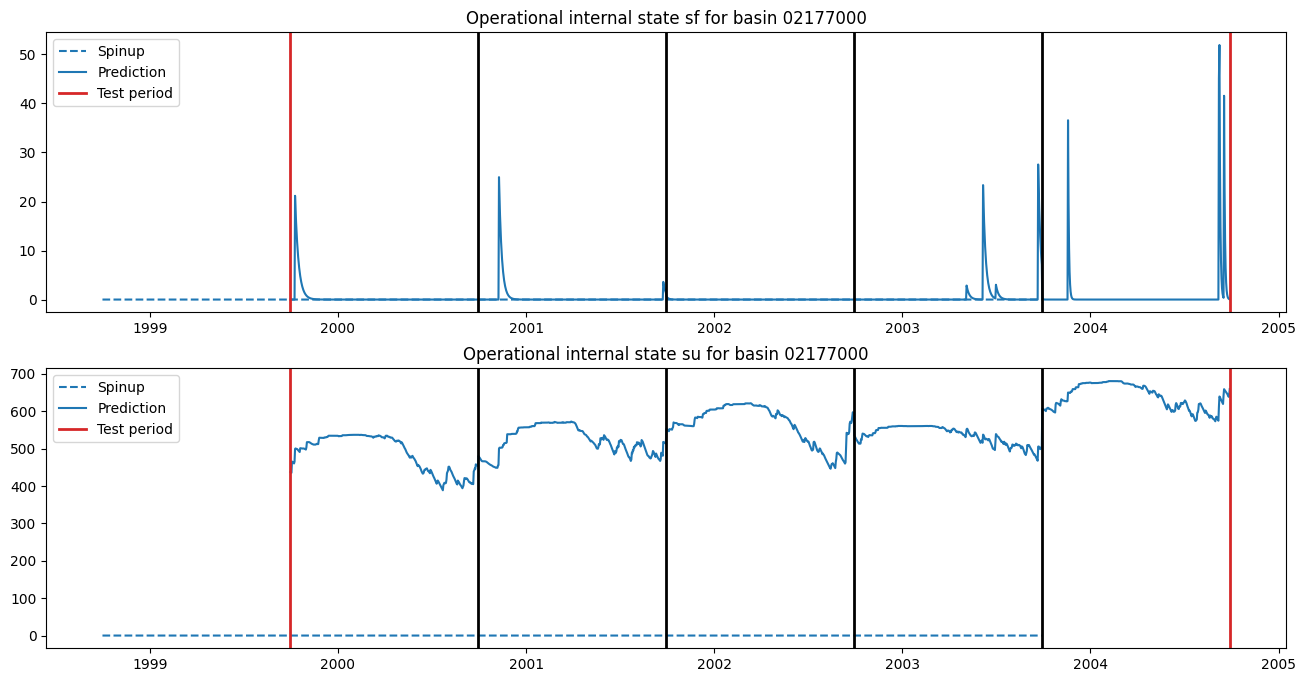

In [99]:
state_interest = state_keys[1]
sf_spinup_operational = xr.DataArray(
    np.hstack(
        [operational_results[basin]['internal_states'][state_interest][0][0:365],
         operational_results[basin]['internal_states'][state_interest][365][0:365],
         operational_results[basin]['internal_states'][state_interest][365*2][0:365],
         operational_results[basin]['internal_states'][state_interest][365*3][0:365],
         operational_results[basin]['internal_states'][state_interest][365*4][0:365],
         np.full(365, np.nan)]
        )
) # this is 2190 long
sf_predict_operational = xr.DataArray(
    np.hstack(
        [np.full(365, np.nan),
        operational_results[basin]['internal_states'][state_interest][0][-365:],
        operational_results[basin]['internal_states'][state_interest][365][-365:],
        operational_results[basin]['internal_states'][state_interest][365*2][-365:],
        operational_results[basin]['internal_states'][state_interest][365*3][-365:],
        operational_results[basin]['internal_states'][state_interest][365*4][-365:]]
            )
) # this is 2190 long

state_interest = state_keys[2]
state_spinup_operational = xr.DataArray(
    np.hstack(
        [operational_results[basin]['internal_states'][state_interest][0][0:365],
         operational_results[basin]['internal_states'][state_interest][365][0:365],
         operational_results[basin]['internal_states'][state_interest][365*2][0:365],
         operational_results[basin]['internal_states'][state_interest][365*3][0:365],
         operational_results[basin]['internal_states'][state_interest][365*4][0:365],
         np.full(365, np.nan)]
        )
) # this is 2190 long
state_predict_operational = xr.DataArray(
    np.hstack(
        [np.full(365, np.nan),
        operational_results[basin]['internal_states'][state_interest][0][-365:],
        operational_results[basin]['internal_states'][state_interest][365][-365:],
        operational_results[basin]['internal_states'][state_interest][365*2][-365:],
        operational_results[basin]['internal_states'][state_interest][365*3][-365:],
        operational_results[basin]['internal_states'][state_interest][365*4][-365:]]
            )
) # this is 2190 long

fig, ax = plt.subplots(figsize=(16,8), nrows=2, ncols=1)
ax[0].plot(dates[:-2], sf_spinup_operational, color="tab:blue", label="Spinup", linestyle='--')
ax[0].plot(dates[:-2], sf_predict_operational, color="tab:blue", label="Prediction")
ax[0].axvline(dates[365], color='tab:red', linewidth=2, label="Test period")
ax[0].axvline(dates[365*2], color='black', linewidth=2)
ax[0].axvline(dates[365*3], color='black', linewidth=2)
ax[0].axvline(dates[365*4], color='black', linewidth=2)
ax[0].axvline(dates[365*5], color='black', linewidth=2)
ax[0].axvline(dates[365*6], color='tab:red', linewidth=2)
ax[0].set_title(f"Operational internal state sf for basin {basin}")
ax[0].legend()

ax[1].plot(dates[:-2], state_spinup_operational, color="tab:blue", label="Spinup", linestyle='--')
ax[1].plot(dates[:-2], state_predict_operational, color="tab:blue", label="Prediction")
ax[1].axvline(dates[365], color='tab:red', linewidth=2, label="Test period")
ax[1].axvline(dates[365*2], color='black', linewidth=2)
ax[1].axvline(dates[365*3], color='black', linewidth=2)
ax[1].axvline(dates[365*4], color='black', linewidth=2)
ax[1].axvline(dates[365*5], color='black', linewidth=2)
ax[1].axvline(dates[365*6], color='tab:red', linewidth=2)
ax[1].set_title(f"Operational internal state {state_interest} for basin {basin}")
ax[1].legend()

## Compare the three models for the same basin

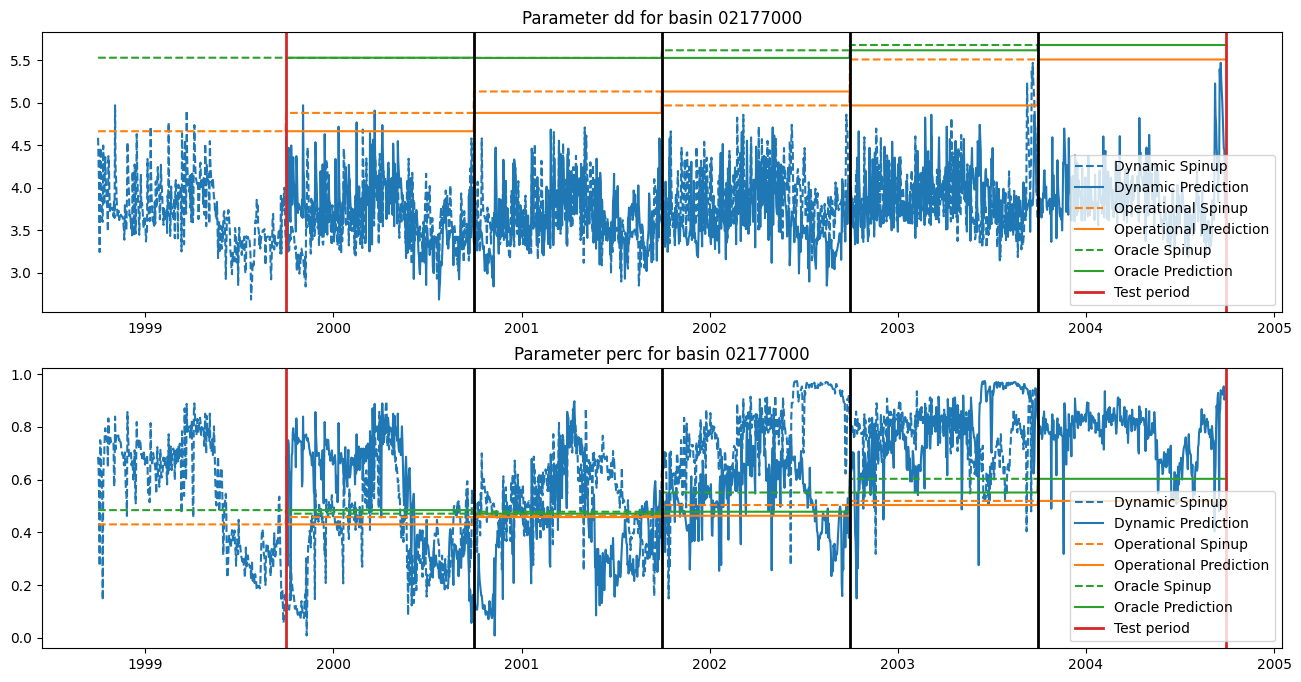

In [102]:
fig, ax = plt.subplots(figsize=(16,8), nrows=2, ncols=1)
ax[0].plot(dates[:-2], dd_spinup_dynamic, color="tab:blue", label="Dynamic Spinup", linestyle='--')
ax[0].plot(dates[:-2], dd_predict_dynamic, color="tab:blue", label="Dynamic Prediction")
ax[0].plot(dates[:-2], dd_spinup_operational, color="tab:orange", label="Operational Spinup", linestyle='--')
ax[0].plot(dates[:-2], dd_predict_operational, color="tab:orange", label="Operational Prediction")
ax[0].plot(dates[:-2], dd_spinup_oracle, color="tab:green", label="Oracle Spinup", linestyle='--')
ax[0].plot(dates[:-2], dd_predict_oracle, color="tab:green", label="Oracle Prediction")
ax[0].axvline(dates[365], color='tab:red', linewidth=2, label="Test period")
ax[0].axvline(dates[365*2], color='black', linewidth=2)
ax[0].axvline(dates[365*3], color='black', linewidth=2)
ax[0].axvline(dates[365*4], color='black', linewidth=2)
ax[0].axvline(dates[365*5], color='black', linewidth=2)
ax[0].axvline(dates[365*6], color='tab:red', linewidth=2)
ax[0].set_title(f"Parameter dd for basin {basin}")
ax[0].legend()

ax[1].plot(dates[:-2], param_spinup_dynamic, color="tab:blue", label="Dynamic Spinup", linestyle='--')
ax[1].plot(dates[:-2], param_predict_dynamic, color="tab:blue", label="Dynamic Prediction")
ax[1].plot(dates[:-2], param_spinup_operational, color="tab:orange", label="Operational Spinup", linestyle='--')
ax[1].plot(dates[:-2], param_predict_operational, color="tab:orange", label="Operational Prediction")
ax[1].plot(dates[:-2], param_spinup_oracle, color="tab:green", label="Oracle Spinup", linestyle='--')
ax[1].plot(dates[:-2], param_predict_oracle, color="tab:green", label="Oracle Prediction")
ax[1].axvline(dates[365], color='tab:red', linewidth=2, label="Test period")
ax[1].axvline(dates[365*2], color='black', linewidth=2)
ax[1].axvline(dates[365*3], color='black', linewidth=2)
ax[1].axvline(dates[365*4], color='black', linewidth=2)
ax[1].axvline(dates[365*5], color='black', linewidth=2)
ax[1].axvline(dates[365*6], color='tab:red', linewidth=2)
ax[1].set_title(f"Parameter {param_interest} for basin {basin}")
ax[1].legend()

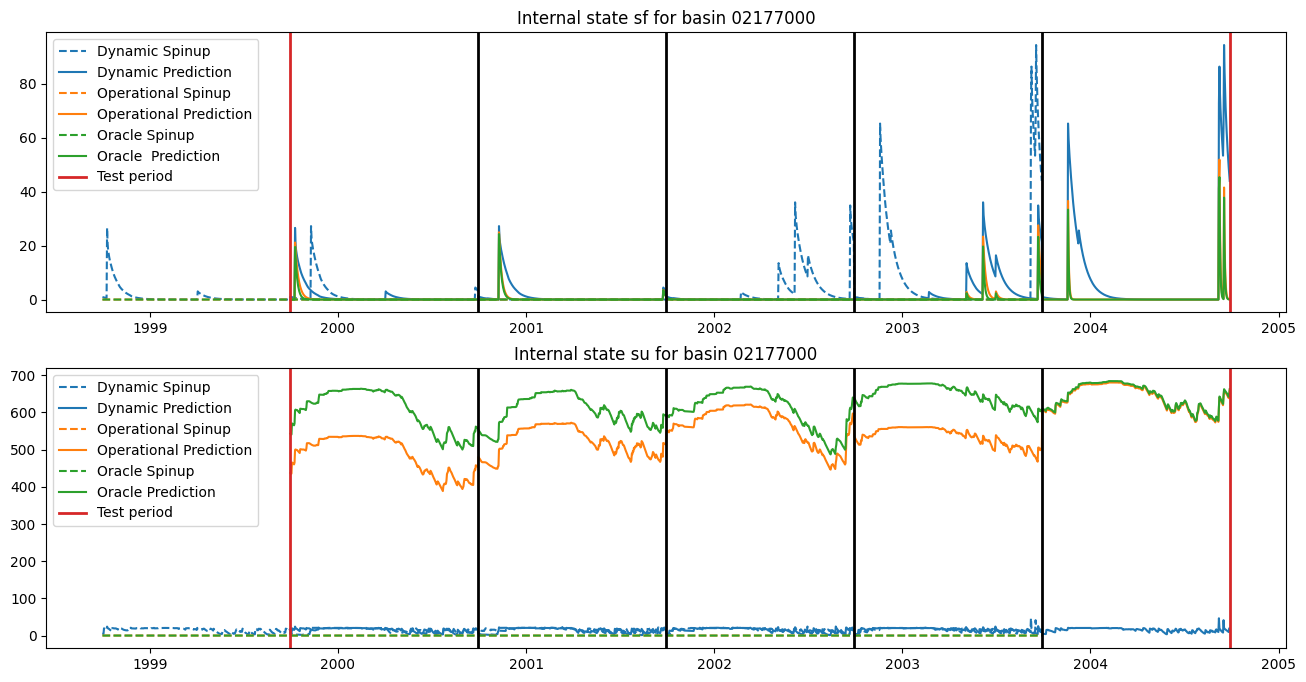

In [104]:
fig, ax = plt.subplots(figsize=(16,8), nrows=2, ncols=1)
ax[0].plot(dates[:-2], sf_spinup_dynamic, color="tab:blue", label="Dynamic Spinup", linestyle='--')
ax[0].plot(dates[:-2], sf_predict_dynamic, color="tab:blue", label="Dynamic Prediction")
ax[0].plot(dates[:-2], sf_spinup_operational, color="tab:orange", label="Operational Spinup", linestyle='--')
ax[0].plot(dates[:-2], sf_predict_operational, color="tab:orange", label="Operational Prediction")
ax[0].plot(dates[:-2], sf_spinup_oracle, color="tab:green", label="Oracle Spinup", linestyle='--')
ax[0].plot(dates[:-2], sf_predict_oracle, color="tab:green", label="Oracle  Prediction")
ax[0].axvline(dates[365], color='tab:red', linewidth=2, label="Test period")
ax[0].axvline(dates[365*2], color='black', linewidth=2)
ax[0].axvline(dates[365*3], color='black', linewidth=2)
ax[0].axvline(dates[365*4], color='black', linewidth=2)
ax[0].axvline(dates[365*5], color='black', linewidth=2)
ax[0].axvline(dates[365*6], color='tab:red', linewidth=2)
ax[0].set_title(f"Internal state sf for basin {basin}")
ax[0].legend()

ax[1].plot(dates[:-2], state_spinup_dynamic, color="tab:blue", label="Dynamic Spinup", linestyle='--')
ax[1].plot(dates[:-2], state_predict_dynamic, color="tab:blue", label="Dynamic Prediction")
ax[1].plot(dates[:-2], state_spinup_operational, color="tab:orange", label="Operational Spinup", linestyle='--')
ax[1].plot(dates[:-2], state_predict_operational, color="tab:orange", label="Operational Prediction")
ax[1].plot(dates[:-2], state_spinup_oracle, color="tab:green", label="Oracle Spinup", linestyle='--')
ax[1].plot(dates[:-2], state_predict_oracle, color="tab:green", label="Oracle Prediction")
ax[1].axvline(dates[365], color='tab:red', linewidth=2, label="Test period")
ax[1].axvline(dates[365*2], color='black', linewidth=2)
ax[1].axvline(dates[365*3], color='black', linewidth=2)
ax[1].axvline(dates[365*4], color='black', linewidth=2)
ax[1].axvline(dates[365*5], color='black', linewidth=2)
ax[1].axvline(dates[365*6], color='tab:red', linewidth=2)
ax[1].set_title(f"Internal state {state_interest} for basin {basin}")
ax[1].legend()